# Part 5 - Guardrail Pipeline

This notebook demonstrates a three-layer moderation pipeline:
1. Regex input filter
2. Calibrated DistilBERT model
3. Human review queue for uncertain predictions

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', '-q', 'transformers>=4.30.0', 'accelerate>=0.21.0', 'scikit-learn==1.5.1', 'pandas==2.2.2', 'numpy==1.26.4', 'matplotlib==3.9.2', 'seaborn==0.13.2', 'joblib'])

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

In [9]:
PROJECT_DIR = Path('/content' if IN_COLAB else '.').resolve()
DATA_PATH = PROJECT_DIR / 'jigsaw-unintended-bias-train.csv'
PIPELINE_PATH = PROJECT_DIR / 'pipeline.py'

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'
assert PIPELINE_PATH.exists(), f'Missing pipeline.py: {PIPELINE_PATH}'

# Optional: if part4 exports were created in the same runtime/workspace
PART4_EXPORT_DIR = PROJECT_DIR / 'part4_mitigations'
print('Project dir:', PROJECT_DIR)
print('Data exists:', DATA_PATH.exists())
print('Part4 export dir exists:', PART4_EXPORT_DIR.exists())

Project dir: C:\Users\Probook\OneDrive\Desktop\Ass2
Data exists: True
Part4 export dir exists: True


In [10]:
import pipeline as pipeline_module
importlib.reload(pipeline_module)

ModerationPipeline = pipeline_module.ModerationPipeline
BLOCKLIST = pipeline_module.BLOCKLIST

print('Loaded pipeline.py successfully')
print('Blocklist categories:', list(BLOCKLIST.keys()))
print('Total regex patterns:', sum(len(v) for v in BLOCKLIST.values()))

Loaded pipeline.py successfully
Blocklist categories: ['direct_threat', 'self_harm_directed', 'doxxing_stalking', 'dehumanization', 'coordinated_harassment']
Total regex patterns: 20


In [11]:
# Recreate Part 1/4 split protocol
usecols = ['comment_text', 'toxic', 'black', 'white']
df = pd.read_csv(DATA_PATH, usecols=usecols, low_memory=False)
df = df.dropna(subset=usecols).copy()
df['label'] = (df['toxic'] >= 0.5).astype(int)
df['is_high_black'] = (df['black'] >= 0.5).astype(int)
df['is_reference'] = ((df['black'] < 0.1) & (df['white'] >= 0.5)).astype(int)

TARGET_TOTAL = 120_000
TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000

subset_df, _ = train_test_split(
    df,
    train_size=TARGET_TOTAL,
    stratify=df['label'],
    random_state=SEED,
)
train_df, eval_df = train_test_split(
    subset_df,
    train_size=TRAIN_SIZE,
    stratify=subset_df['label'],
    random_state=SEED,
)

print('Eval rows:', len(eval_df))
print('Eval toxic rate:', round(eval_df['label'].mean(), 4))

Eval rows: 20000
Eval toxic rate: 0.1135


In [12]:
# Resolve model path for Part 5
# Priority: best_mitigated/model -> reweighing_model -> oversampling_model -> part1_baseline
candidate_paths = [
    PART4_EXPORT_DIR / 'best_mitigated' / 'model',
    PART4_EXPORT_DIR / 'reweighing_model',
    PART4_EXPORT_DIR / 'oversampling_model',
    PROJECT_DIR / 'part1_baseline',
]

MODEL_DIR = None
for p in candidate_paths:
    if p.exists() and (p / 'config.json').exists():
        MODEL_DIR = p
        break

assert MODEL_DIR is not None, 'No usable model directory found. Run Part 4 export cell or upload part1_baseline.'
print('Using model dir:', MODEL_DIR)

Using model dir: C:\Users\Probook\OneDrive\Desktop\Ass2\part4_mitigations\reweighing_model


In [13]:
# Split eval for calibration and demo
cal_df, demo_pool = train_test_split(
    eval_df,
    train_size=5000,
    stratify=eval_df['label'],
    random_state=SEED,
)

demo_df = demo_pool.sample(n=1000, random_state=SEED).reset_index(drop=True)
cal_df = cal_df.reset_index(drop=True)

print('Calibration rows:', len(cal_df))
print('Demo rows:', len(demo_df))

Calibration rows: 5000
Demo rows: 1000


In [14]:
pipe = ModerationPipeline(
    model_dir=str(MODEL_DIR),
    lower_threshold=0.4,
    upper_threshold=0.6,
)

pipe.fit_calibrator(
    calibration_texts=cal_df['comment_text'].tolist(),
    calibration_labels=cal_df['label'].astype(int).tolist(),
    batch_size=64,
)

print('Pipeline and isotonic calibrator are ready.')

c:\Users\Probook\OneDrive\Desktop\Ass2\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Pipeline and isotonic calibrator are ready.


In [15]:
# Run pipeline on 1,000 examples
records = []
for _, row in demo_df.iterrows():
    out = pipe.predict(str(row['comment_text']))
    records.append({
        'y_true': int(row['label']),
        'decision': out.get('decision', 'unknown'),
        'layer': out.get('layer', 'unknown'),
        'category': out.get('category', 'none'),
        'confidence': float(out.get('confidence', np.nan)),
    })

results_df = pd.DataFrame(records)
results_df['route'] = np.where(
    results_df['layer'] == 'input_filter',
    'input_filter',
    np.where(results_df['decision'] == 'review', 'review_queue', 'model_auto')
)

display(results_df.head())
print('Total processed:', len(results_df))

,y_true,decision,layer,category,confidence,route
0,0,allow,model,none,0.149542,model_auto
1,0,allow,model,none,0.029657,model_auto
2,0,allow,model,none,0.009074,model_auto
3,1,block,model,none,0.985507,model_auto
4,0,allow,model,none,0.180248,model_auto


Total processed: 1000


,route,count,fraction
0,model_auto,975,0.975
1,review_queue,25,0.025


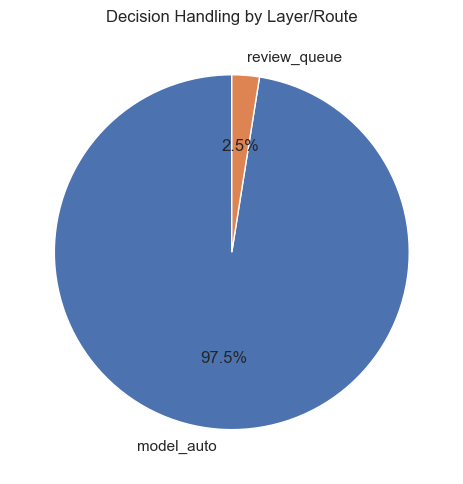

In [16]:
# Layer-distribution plot
route_counts = results_df['route'].value_counts().rename_axis('route').reset_index(name='count')
route_counts['fraction'] = route_counts['count'] / len(results_df)
display(route_counts)

plt.figure(figsize=(7, 5))
plt.pie(route_counts['count'], labels=route_counts['route'], autopct='%1.1f%%', startangle=90)
plt.title('Decision Handling by Layer/Route')
plt.tight_layout()
plt.show()

In [17]:
# Input-filter category breakdown
blocked_by_filter = results_df[results_df['layer'] == 'input_filter']
if len(blocked_by_filter) > 0:
    cat_counts = blocked_by_filter['category'].value_counts().rename_axis('category').reset_index(name='count')
else:
    cat_counts = pd.DataFrame({'category': [], 'count': []})

print('Blocked by input filter:', len(blocked_by_filter))
display(cat_counts)

Blocked by input filter: 0


,category,count


In [18]:
# Auto-action metrics for Layer 2 confident decisions only
auto_df = results_df[(results_df['layer'] == 'model') & (results_df['decision'].isin(['block', 'allow']))].copy()

if len(auto_df) == 0:
    print('No model auto-actions available at current thresholds.')
else:
    y_true_auto = auto_df['y_true'].astype(int).values
    y_pred_auto = (auto_df['decision'] == 'block').astype(int).values

    print('Auto-action rows:', len(auto_df))
    print('F1:', round(f1_score(y_true_auto, y_pred_auto), 4))
    print('Precision:', round(precision_score(y_true_auto, y_pred_auto, zero_division=0), 4))
    print('Recall:', round(recall_score(y_true_auto, y_pred_auto, zero_division=0), 4))

Auto-action rows: 975
F1: 0.5312
Precision: 0.7727
Recall: 0.4048


In [19]:
# Review-queue toxic/non-toxic breakdown
review_df = results_df[results_df['decision'] == 'review'].copy()

print('Review queue rows:', len(review_df))
if len(review_df) > 0:
    breakdown = review_df['y_true'].value_counts().sort_index().rename(index={0: 'non_toxic', 1: 'toxic'})
    display(breakdown.to_frame('count'))
    print('Toxic rate in review queue:', round(review_df['y_true'].mean(), 4))

Review queue rows: 25


,count
y_true,
non_toxic,11
toxic,14


Toxic rate in review queue: 0.56


In [20]:
# Threshold-band sensitivity analysis
def evaluate_band(lower, upper, df):
    pipe.set_uncertainty_band(lower, upper)

    tmp = []
    for _, row in df.iterrows():
        out = pipe.predict(str(row['comment_text']))
        tmp.append({
            'y_true': int(row['label']),
            'decision': out.get('decision', 'unknown'),
            'layer': out.get('layer', 'unknown'),
        })
    tmp_df = pd.DataFrame(tmp)

    auto = tmp_df[(tmp_df['layer'] == 'model') & (tmp_df['decision'].isin(['block', 'allow']))].copy()
    review = tmp_df[tmp_df['decision'] == 'review'].copy()

    if len(auto) > 0:
        y_true_auto = auto['y_true'].astype(int).values
        y_pred_auto = (auto['decision'] == 'block').astype(int).values
        f1_val = f1_score(y_true_auto, y_pred_auto)
        p_val = precision_score(y_true_auto, y_pred_auto, zero_division=0)
        r_val = recall_score(y_true_auto, y_pred_auto, zero_division=0)
    else:
        f1_val = np.nan
        p_val = np.nan
        r_val = np.nan

    return {
        'band': f'{lower:.2f}-{upper:.2f}',
        'auto_fraction': len(auto) / len(tmp_df),
        'review_fraction': len(review) / len(tmp_df),
        'auto_f1': f1_val,
        'auto_precision': p_val,
        'auto_recall': r_val,
        'review_toxic_rate': review['y_true'].mean() if len(review) > 0 else np.nan,
    }

bands = [(0.4, 0.6), (0.45, 0.55), (0.3, 0.7)]
band_rows = [evaluate_band(lo, hi, demo_df) for lo, hi in bands]
band_df = pd.DataFrame(band_rows)
display(band_df)

,band,auto_fraction,review_fraction,auto_f1,auto_precision,auto_recall,review_toxic_rate
0,0.40-0.60,0.975,0.025,0.531250,0.772727,0.404762,0.560000
1,0.45-0.55,0.991,0.009,0.556291,0.711864,0.456522,0.666667
2,0.30-0.70,0.929,0.071,0.543478,0.862069,0.396825,0.492958


In [22]:
print('Rows processed:', len(results_df))
print('\nRoute counts:')
print(route_counts.to_string(index=False))
print('\nInput-filter categories:')
print(cat_counts.to_string(index=False) if len(cat_counts) else 'None')
print('\nAuto-action metrics:')
if len(auto_df) == 0:
    print('No model auto-actions available at current thresholds.')
else:
    y_true_auto = auto_df['y_true'].astype(int).values
    y_pred_auto = (auto_df['decision'] == 'block').astype(int).values
    print('Auto-action rows:', len(auto_df))
    print('F1:', round(f1_score(y_true_auto, y_pred_auto), 4))
    print('Precision:', round(precision_score(y_true_auto, y_pred_auto, zero_division=0), 4))
    print('Recall:', round(recall_score(y_true_auto, y_pred_auto, zero_division=0), 4))
print('\nReview-queue breakdown:')
if len(review_df) == 0:
    print('No review queue rows.')
else:
    print(review_df['y_true'].value_counts().sort_index().rename(index={0: 'non_toxic', 1: 'toxic'}).to_string())
    print('Toxic rate in review queue:', round(review_df['y_true'].mean(), 4))
print('\nBand sensitivity:')
print(band_df.to_string(index=False))

Rows processed: 1000

Route counts:
       route  count  fraction
  model_auto    975     0.975
review_queue     25     0.025

Input-filter categories:
None

Auto-action metrics:
Auto-action rows: 975
F1: 0.5312
Precision: 0.7727
Recall: 0.4048

Review-queue breakdown:
y_true
non_toxic    11
toxic        14
Toxic rate in review queue: 0.56

Band sensitivity:
     band  auto_fraction  review_fraction  auto_f1  auto_precision  auto_recall  review_toxic_rate
0.40-0.60          0.975            0.025 0.531250        0.772727     0.404762           0.560000
0.45-0.55          0.991            0.009 0.556291        0.711864     0.456522           0.666667
0.30-0.70          0.929            0.071 0.543478        0.862069     0.396825           0.492958


## Discussion Prompt

- Is 0.4-0.6 the right uncertainty band?

Ans: The default uncertainty band of 0.4-0.6 is the most balanced choice. It keeps review volume low while still reserving uncertain cases for humans.

- How do review volume and auto-action quality change at 0.45-0.55 and 0.3-0.7?

Ans:The 0.45-0.55 band is more aggressive: it raises F1 slightly to 0.5563 and recall to 0.4565, but precision drops to 0.7119 and the review queue shrinks to only 0.9% of cases. The 0.3-0.7 band is more conservative: it increases precision to 0.8621, but recall falls to 0.3968 and the review queue grows to 7.1%.

- Which band would you choose for production and why?

Ans: If I had to choose one for production, I would keep 0.4-0.6 as the best balance of safety, throughput, and review burden but if the priority is minimizing false positives more than review volume, then 0.3-0.7 is the safer alternative.